<a href="https://colab.research.google.com/github/Sanataniitb/autoimmune-disease/blob/main/notebooks/original/spondylitis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Seminar_Sanatan/MTP/ML Codes/Spondylitis_ml input_80 features.csv")

In [ ]:
data.shape

(83, 67)

In [ ]:
data.head()

,Gene,AS1,AS2,AS3,AS4,AS5,AS6,AS7,AS8,AS9,...,Health_34,Health_35,Health_36,Health_37,Health_38,Health_39,Health_40,Health_41,Health_42,Health_43
0,PGLYRP1,3,21,0,0,1,1,27,1,4,...,1311,249,1150,832,263,562,1022,75,853,239
1,RUNX3,953,2595,3052,2079,1471,1467,1459,1980,4387,...,6075,1697,9505,4081,4473,2378,7126,1690,5760,1615
2,ENTPD2,2,2,1,0,0,1,2,0,0,...,17,48,38,114,0,24,153,5,20,123
3,SPI1,757,2003,1810,1138,1018,2012,2313,943,1558,...,14702,5191,19574,12723,4962,5119,21059,2416,11612,8007
4,TNFRSF1A,1033,4535,4282,2691,2844,2528,2279,1626,1281,...,12916,3634,18128,13439,5975,6837,20487,4196,17544,5989


In [ ]:
cols=list(data.Gene)
#cols=list(data['Unnamed: 0'])

In [ ]:
data=data.T

In [ ]:
data.columns=cols

In [ ]:
data["target"]=data.index

In [ ]:
data.reset_index(inplace=True)

In [ ]:
data.head()

,index,PGLYRP1,RUNX3,ENTPD2,SPI1,TNFRSF1A,POLR2F,PYGL,MMP9,PRSS33,...,NPIPB5,HBB,CEBPA,PTTG2,NPIPA2,TAS2R30,SMIM3,MYZAP,KMT2B,target
0,Gene,PGLYRP1,RUNX3,ENTPD2,SPI1,TNFRSF1A,POLR2F,PYGL,MMP9,PRSS33,...,NPIPB5,HBB,CEBPA,PTTG2,NPIPA2,TAS2R30,SMIM3,MYZAP,KMT2B,Gene
1,AS1,3,953,2,757,1033,22,1372,8,2,...,41,19307,506,49,0,377,287,18,1227,AS1
2,AS2,21,2595,2,2003,4535,3,6877,85,0,...,10,8528,1955,11,0,36,1116,87,1304,AS2
3,AS3,0,3052,1,1810,4282,4,5138,12,0,...,21,15896,1745,18,0,104,841,83,1987,AS3
4,AS4,0,2079,0,1138,2691,3,4439,7,1,...,21,3015,1220,11,0,92,423,122,1073,AS4


In [ ]:
data.drop(index=data.index[0],axis=0,inplace=True)

In [ ]:
def val(row):
    if row[0]=="A":
        return 1
    else:
        return 0

In [ ]:
data["target"]=data.target.apply(val)

In [ ]:
data.head()

,index,PGLYRP1,RUNX3,ENTPD2,SPI1,TNFRSF1A,POLR2F,PYGL,MMP9,PRSS33,...,NPIPB5,HBB,CEBPA,PTTG2,NPIPA2,TAS2R30,SMIM3,MYZAP,KMT2B,target
1,AS1,3,953,2,757,1033,22,1372,8,2,...,41,19307,506,49,0,377,287,18,1227,1
2,AS2,21,2595,2,2003,4535,3,6877,85,0,...,10,8528,1955,11,0,36,1116,87,1304,1
3,AS3,0,3052,1,1810,4282,4,5138,12,0,...,21,15896,1745,18,0,104,841,83,1987,1
4,AS4,0,2079,0,1138,2691,3,4439,7,1,...,21,3015,1220,11,0,92,423,122,1073,1
5,AS5,1,1471,0,1018,2844,5,3947,14,0,...,9,6153,971,7,0,56,556,75,989,1


In [ ]:
data.drop("index",axis=1,inplace=True)

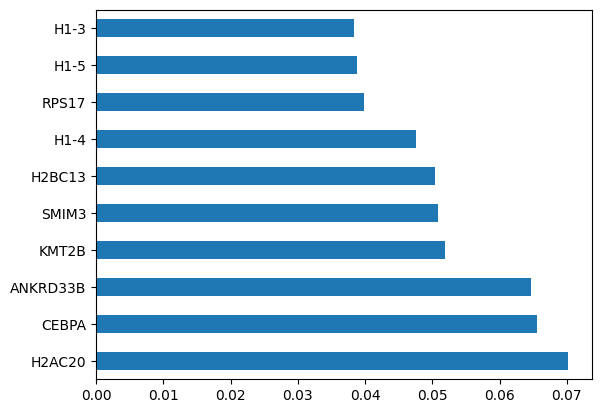

In [ ]:
import numpy as np

X = data.iloc[:,0:-1]  #independent columns
y = data.iloc[:,-1]    #target column i.e price range
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
model = ExtraTreesClassifier()
model.fit(X,y)
#print(model.feature_importances_) #use inbuilt class feature_importances of tree based classifiers
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
important_feature=list(feat_importances[feat_importances>0.003].index)

In [ ]:
# l=["HLA-DQB1",
# "INS",
# "PTPN22",
# "CTLA4",
# "IL2RA",
# "IFIH1",
# "ERBB3",
# "CLEC16A",
# "SUMO4",
# "HLA-DRB1"]
# important_feature=important_feature+l

In [ ]:
len(important_feature)

41

In [ ]:
x=data.drop("target",axis=1)

In [ ]:
x=x[important_feature]

In [ ]:
x.head()

,ENTPD2,SPI1,TNFRSF1A,POLR2F,MMP9,SIGLEC8,KRT23,AREG,MANSC1,OTX1,...,H4C3,ATP6V1G2,NPIPB5,CEBPA,PTTG2,NPIPA2,TAS2R30,SMIM3,MYZAP,KMT2B
1,2,757,1033,22,8,0,11,77,11,0,...,530,28,41,506,49,0,377,287,18,1227
2,2,2003,4535,3,85,3,96,96,44,0,...,1476,23,10,1955,11,0,36,1116,87,1304
3,1,1810,4282,4,12,0,35,82,83,1,...,2423,55,21,1745,18,0,104,841,83,1987
4,0,1138,2691,3,7,0,25,55,40,0,...,1422,27,21,1220,11,0,92,423,122,1073
5,0,1018,2844,5,14,0,53,12,26,0,...,1358,33,9,971,7,0,56,556,75,989


In [ ]:
import numpy as np

def standardize_features_by_class(X, y):
    classes = np.unique(y)
    standardized_features = []

    for cls in classes:
        class_features = X[y == cls]
        class_means = np.mean(class_features, axis=0)
        class_stds = np.std(class_features, axis=0)
        standardized_class_features = (class_features - class_means) / (class_stds+1)
        standardized_features.append(standardized_class_features)
    standardized_X = np.concatenate(standardized_features)

    return standardized_X

standardized_X = standardize_features_by_class(x, y)

In [ ]:
x.head()

,ENTPD2,SPI1,TNFRSF1A,POLR2F,MMP9,SIGLEC8,KRT23,AREG,MANSC1,OTX1,...,H4C3,ATP6V1G2,NPIPB5,CEBPA,PTTG2,NPIPA2,TAS2R30,SMIM3,MYZAP,KMT2B
1,2,757,1033,22,8,0,11,77,11,0,...,530,28,41,506,49,0,377,287,18,1227
2,2,2003,4535,3,85,3,96,96,44,0,...,1476,23,10,1955,11,0,36,1116,87,1304
3,1,1810,4282,4,12,0,35,82,83,1,...,2423,55,21,1745,18,0,104,841,83,1987
4,0,1138,2691,3,7,0,25,55,40,0,...,1422,27,21,1220,11,0,92,423,122,1073
5,0,1018,2844,5,14,0,53,12,26,0,...,1358,33,9,971,7,0,56,556,75,989


In [ ]:
y=data["target"]

In [ ]:
y.head()

1    1
2    1
3    1
4    1
5    1
Name: target, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( standardized_X, y, test_size=0.23, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn import svm

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
y_tpred = classifier.predict(X_train)

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print ("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[8 2]
 [5 1]]


In [ ]:
from sklearn.metrics import accuracy_score
print ("Accuracy train : ", accuracy_score(y_train, y_tpred))
print ("Accuracy test: ", accuracy_score(y_test, y_pred))

Accuracy train :  0.82
Accuracy test:  0.5625


In [ ]:
from sklearn.metrics import f1_score
print ("f1_score train : ", f1_score(y_train, y_tpred,average="macro"))
print ("f1_score test: ", f1_score(y_test, y_pred,average="macro"))

f1_score train :  0.7716894977168951
f1_score test:  0.45893719806763283


Text(50.722222222222214, 0.5, 'actual')

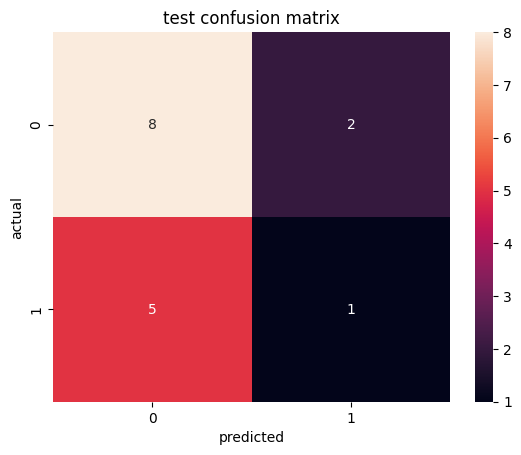

In [ ]:
import seaborn as sn
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

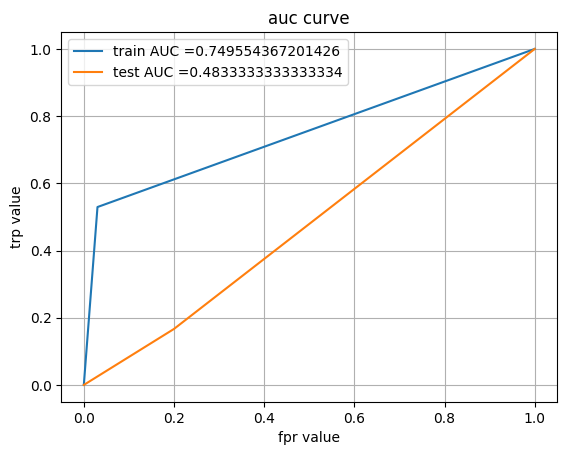

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_tpred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_pred)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

0.66
0.625
F1 score train :  0.39759036144578314
F1 score test:  0.38461538461538464


Text(50.722222222222214, 0.5, 'actual')

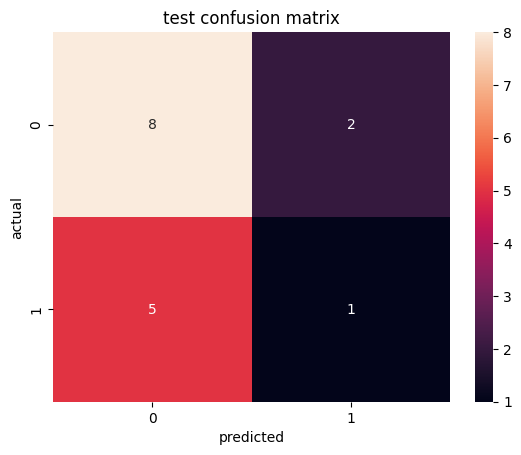

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix

svc_model = SVC(C=0.5, kernel='rbf', gamma=1)
svc_model.fit(X_train, y_train)
prediction_t = svc_model .predict(X_train)
prediction = svc_model .predict(X_test)
# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))
from sklearn.metrics import f1_score
print ("F1 score train : ", f1_score(y_train, prediction_t,average="macro"))
print ("F1 score test: ", f1_score(y_test, prediction,average="macro"))
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

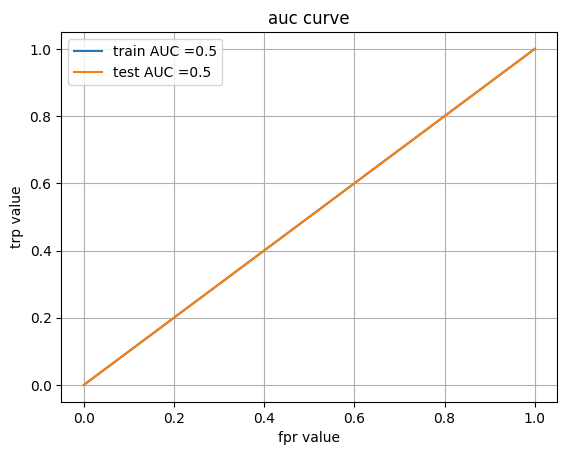

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, prediction_t)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, prediction)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
gbdt=XGBClassifier()
parameters ={"max_depth":[3,4,5,6,7],"n_estimators":[10,50,100,150,200]}
clf1 = GridSearchCV(gbdt, parameters, cv=4,n_jobs=-1,scoring='f1_macro',return_train_score=True)
clf1.fit(X_train, y_train)
clf1.best_estimator_.get_params()

{'objective': 'binary:logistic',
 'use_label_encoder': None,
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'gpu_id': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 4,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'n_estimators': 10,
 'n_jobs': None,
 'num_parallel_tree': None,
 'predictor': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

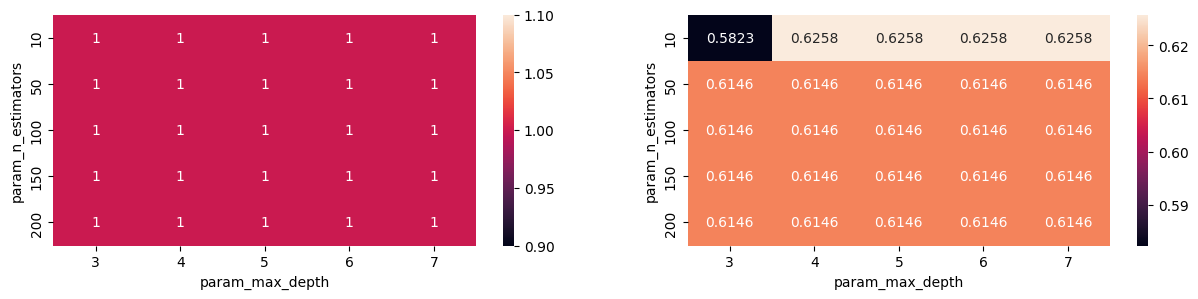

In [ ]:
import pandas as pd
import seaborn as sn
fig=plt.figure(figsize=(15,3))
a=fig.add_subplot(121)
result=pd.DataFrame.from_dict(clf1.cv_results_)
max_score=result.groupby(["param_n_estimators","param_max_depth"]).max()
max_score=max_score.unstack()[["mean_test_score","mean_train_score"]]
a=sn.heatmap(max_score.mean_train_score,annot=True,fmt=".4g")
b=fig.add_subplot(122)
a=sn.heatmap(max_score.mean_test_score,annot=True,fmt=".4g")

In [ ]:
def batch_predict(clf, data):
    # roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
    # not the predicted outputs

    y_data_pred = []
    tr_loop = data.shape[0] - data.shape[0]%1000
    for i in range(0, tr_loop, 1000):
        y_data_pred.extend(clf.predict_proba(data[i:i+1000])[:,1])
    # we will be predicting for the last data points
    if data.shape[0]%1000 !=0:
        y_data_pred.extend(clf.predict_proba(data[tr_loop:])[:,1])

    return y_data_pred

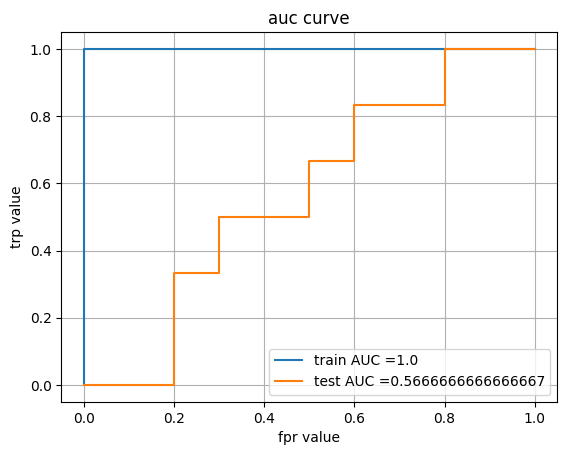

In [ ]:
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
gbdt1 = XGBClassifier(max_depth=4,n_estimators=150)
gbdt1.fit(X_train, y_train)

y_train_pred1 = batch_predict(gbdt1, X_train)
y_test_pred1= batch_predict(gbdt1, X_test)

train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred1)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred1)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
def find_best_threshold(threshould, fpr, tpr):
    t = threshould[np.argmax(tpr*(1-fpr))]
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    #print("the maximum value of tpr*(1-fpr)", max(tpr*(1-fpr)), "for threshold", np.round(t,3))
    return t

def predict_with_best_t(proba, threshould):
    predictions = []
    for i in proba:
        if i>=threshould:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

Text(792.3131313131312, 0.5, 'actual')

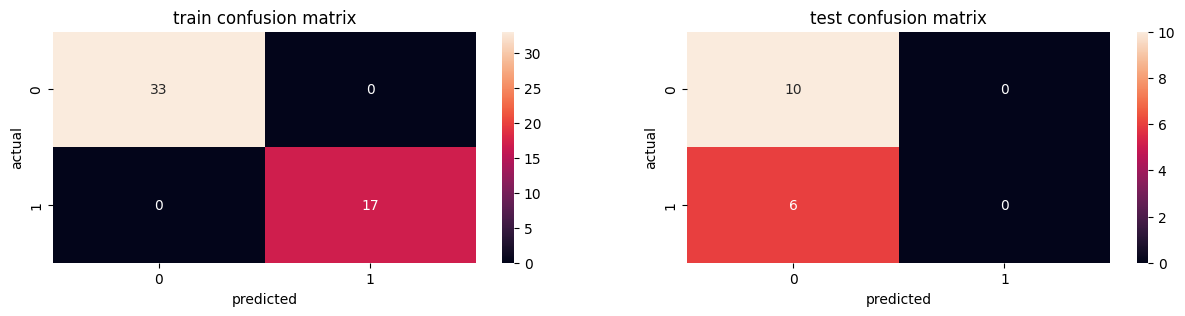

In [ ]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)
k=confusion_matrix(y_train, predict_with_best_t(y_train_pred1, best_t))
fig=plt.figure(figsize=(15,3))
a=fig.add_subplot(121)
a=sn.heatmap(k,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
a.set_title("train confusion matrix")
a.set_xlabel("predicted")
a.set_ylabel("actual")
b=fig.add_subplot(122)
y_pred=predict_with_best_t(y_test_pred1, best_t)
c_test=confusion_matrix(y_test, y_pred)
b=sn.heatmap(c_test,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

In [ ]:
print(accuracy_score(y_train, predict_with_best_t(y_train_pred1, best_t)))
print(accuracy_score(y_test, predict_with_best_t(y_test_pred1, best_t)))

from sklearn.metrics import f1_score
print ("f1_score train : ", f1_score(y_train, y_tpred,average="macro"))
print ("f1_score test: ", f1_score(y_test, y_pred,average="macro"))

1.0
0.625
f1_score train :  0.7716894977168951
f1_score test:  0.38461538461538464


In [ ]:
a=X_test[3:4]

In [ ]:
if gbdt1.predict(a)[0]==1:
  print("disease")
else:
  print("healthy")

healthy


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dense, Dropout
from keras.regularizers import l2
from keras.optimizers import Adam
input_dim = x.shape[1]
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=input_dim))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from sklearn.model_selection import train_test_split
x = np.asarray(standardized_X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
import numpy as np

# # Train the model
# model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1,validation_data=(X_test, y_test))

# # Evaluate the model
# loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
# print('Test loss:', loss)
# print('Test accuracy:', accuracy)

In [ ]:
from keras.callbacks import TensorBoard

# Create a TensorBoard callback
tensorboard_callback = TensorBoard(log_dir='./logs', histogram_freq=1)

# Train the model
history = model.fit(X_train, y_train, epochs=12, batch_size=16, verbose=1,
                    validation_data=(X_test, y_test), callbacks=[tensorboard_callback])

Epoch 1/12
4/4 [==============================] - 8s 419ms/step - loss: 1.0963 - accuracy: 0.2500 - val_loss: 0.9960 - val_accuracy: 0.4286
Epoch 2/12
4/4 [==============================] - 0s 126ms/step - loss: 0.9724 - accuracy: 0.5962 - val_loss: 0.9766 - val_accuracy: 0.5714
Epoch 3/12
4/4 [==============================] - 0s 132ms/step - loss: 0.9147 - accuracy: 0.6923 - val_loss: 0.9597 - val_accuracy: 0.5714
Epoch 4/12
4/4 [==============================] - 0s 135ms/step - loss: 0.9205 - accuracy: 0.6731 - val_loss: 0.9466 - val_accuracy: 0.5714
Epoch 5/12
4/4 [==============================] - 0s 81ms/step - loss: 0.8813 - accuracy: 0.6923 - val_loss: 0.9335 - val_accuracy: 0.5714
Epoch 6/12
4/4 [==============================] - 0s 70ms/step - loss: 0.8502 - accuracy: 0.7308 - val_loss: 0.9232 - val_accuracy: 0.5714
Epoch 7/12
4/4 [==============================] - 0s 85ms/step - loss: 0.8503 - accuracy: 0.6923 - val_loss: 0.9272 - val_accuracy: 0.5714
Epoch 8/12
4/4 [=======

In [ ]:

%load_ext tensorboard
%tensorboard --logdir logs

In [ ]:
model.evaluate(X_test, y_test)

1/1 [==============================] - 0s 27ms/step - loss: 0.8643 - accuracy: 0.6429


[0.8642907738685608, 0.6428571343421936]

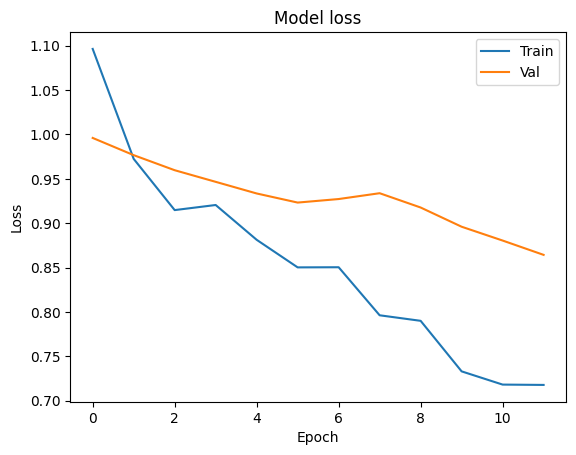

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

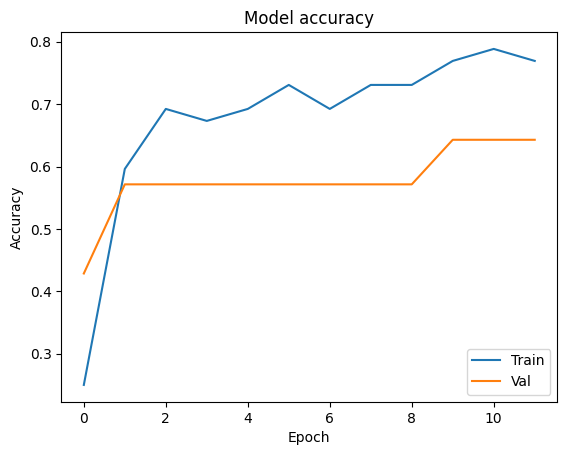

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [ ]:
if model.predict(X_test[5:6])[0][0]<0.5:
  print("healthy")
else:
  print("disease")

1/1 [==============================] - 0s 141ms/step
healthy


In [ ]:
def predict_with_best_t(proba):
    predictions = []
    for i in proba:
        if i>=0.5:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

In [ ]:
y_tpred=model.predict(X_train)
y_pred=model.predict(X_test)

1/1 [==============================] - 0s 17ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predict_with_best_t(y_pred))
print ("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[8 0]
 [5 1]]


Text(50.722222222222214, 0.5, 'actual')

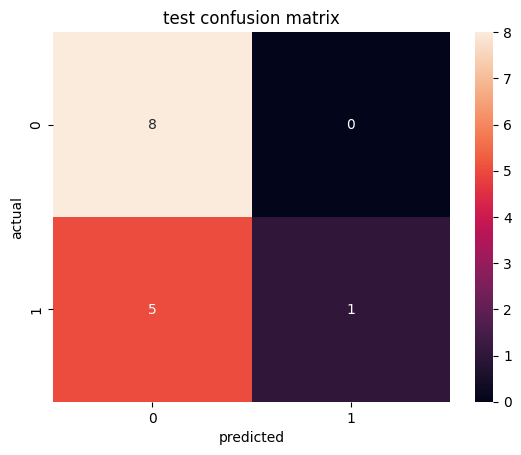

In [ ]:
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

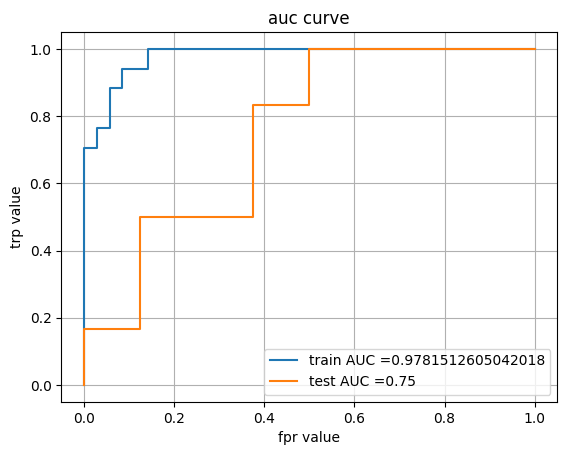

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_tpred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_pred)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print('Precision: %.3f' % precision_score(y_test, predict_with_best_t(y_pred)))
print('Recall: %.3f' % recall_score(y_test, predict_with_best_t(y_pred)))

Precision: 1.000
Recall: 0.167
